# Isotope Generator Calculator

Simulates parent→daughter activity over time with fixed-interval milking, using the same physics as the web app.

**Usage:** Edit the **Parameters** cell, then run all cells (`Kernel → Restart & Run All`).

In [ ]:
import sys, math, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.linalg import expm

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from app.physics import (
    simulate_generator,
    activity_from_atoms, infer_duration, infer_duration_chain,
)

LN2 = math.log(2)
DB_PATH = ROOT / 'instance' / 'generator.db'
MBQ_PER_MCI = 37

TIME_UNITS = [
    ('s',         1 / 3600),
    ('min',       1 / 60),
    ('h',         1.0),
    ('d',         24.0),
    ('months',    30.4375 * 24),
    ('y',         365.25 * 24),
    ('decades',   10 * 365.25 * 24),
    ('centuries', 100 * 365.25 * 24),
]

def pick_time_unit(half_life_h):
    for label, h_per_unit in TIME_UNITS:
        if 1 <= half_life_h / h_per_unit < 100:
            return label, h_per_unit
    return TIME_UNITS[-1]

def _db_half_life(db, symbol):
    row = db.execute('SELECT half_life_s FROM isotopes WHERE symbol = ?', (symbol,)).fetchone()
    return row[0] if row else None

def _db_branching_ratio(db, parent, daughter):
    row = db.execute(
        'SELECT branching_ratio FROM decay_modes WHERE parent_symbol=? AND daughter_symbol=?',
        (parent, daughter),
    ).fetchone()
    return row[0] if row else 1.0

def simulate_chain(
    lambdas: list[float],
    branching_ratios: list[float],
    N0_first: float,
    milking_interval_s: float,
    duration_s: float,
    n_points_per_interval: int = 20,
) -> dict:
    """
    Simulate an N-member linear decay chain with fixed-interval milking of the last species.

    Uses the matrix exponential of the ODE coefficient matrix — exact for any chain length,
    no degenerate-case handling required. Only the last species is harvested at each milking;
    all intermediates carry over.

    lambdas: decay constants [λ0, λ1, ..., λ_{N-1}] in s⁻¹
    branching_ratios: [br0, br1, ..., br_{N-2}] — br_i is the fraction of λ_i that feeds λ_{i+1}
    N0_first: initial atom count of the first (parent) species
    Returns: t_seconds, N_values (list of N arrays, one per species), milking_events
    """
    num_isotopes_in_chain = len(lambdas)

    # Tridiagonal ODE matrix: A[i,i] = -λi, A[i+1,i] = br_i * λ_i
    A = np.diag(-np.array(lambdas, dtype=float))
    for i in range(num_isotopes_in_chain - 1):
        A[i + 1, i] = branching_ratios[i] * lambdas[i]

    segment_bounds = np.concatenate(([0.0]
                                     , np.arange(milking_interval_s, duration_s, milking_interval_s)
                                    ,[duration_s]))

    t_global = []
    N_global = [[] for _ in range(num_isotopes_in_chain)]
    milking_events = []

    N_seg = np.zeros(num_isotopes_in_chain)
    N_seg[0] = N0_first

    for i in range(len(segment_bounds) - 1):
        t_start = segment_bounds[i]
        t_end = segment_bounds[i + 1]
        local_t = np.linspace(0.0, t_end - t_start, n_points_per_interval)

        # Exact solution: N(t) = expm(A·t) @ N_seg
        N_at_t = np.stack([expm(A * t) @ N_seg for t in local_t])

        t_global.append(t_start + local_t)
        for k in range(num_isotopes_in_chain):
            N_global[k].append(N_at_t[:, k])

        is_milking = i < len(segment_bounds) - 2
        if is_milking:
            N_end = N_at_t[-1]
            yield_atoms = float(N_end[-1])
            milking_events.append((float(t_end), yield_atoms))
            N_seg = N_end.copy()
            N_seg[-1] = 0.0  # harvest last species; intermediates carry over
        else:
            N_seg = N_at_t[-1]

    return {
        't_seconds': np.concatenate(t_global),
        'N_values': [np.concatenate(N_global[k]) for k in range(num_isotopes_in_chain)],
        'milking_events': milking_events,
    }


## Parameters

Edit the values below. Run the rest of the notebook after changing them.

- `INTERMEDIATE_SYMBOLS`: leave as `[]` for a direct parent→daughter pair, or add intermediates, e.g. `['Ra-225']` for Th-229→Ra-225→Ac-225.
- Provide `DURATION_H`, `MIN_YIELD`, or both. If only `MIN_YIELD` is given the duration is inferred automatically.

In [11]:
# ── Generator pair ────────────────────────────────────────────────────────
PARENT_SYMBOL        = 'Ra-225'
DAUGHTER_SYMBOL      = 'Ac-225'
INTERMEDIATE_SYMBOLS = []       # e.g. ['Ra-225'] for Th-229 → Ra-225 → Ac-225

# ── Simulation parameters ─────────────────────────────────────────────────
UNITS                = 'MBq'   # 'MBq' or 'mCi'
INITIAL_ACTIVITY     = 37000   # in UNITS
MILKING_INTERVAL_H   = 24.0    # hours
GENERATOR_YIELD_PCT  = 100     # %

# ── Duration / threshold (at least one required) ──────────────────────────
DURATION_H           = 336.0   # hours; set to None to auto-infer from MIN_YIELD
MIN_YIELD            = None    # practical min yield in UNITS; None if using fixed DURATION_H

## Calculation

In [12]:
def to_mbq(v):
    return v * MBQ_PER_MCI if UNITS == 'mCi' else float(v)

def from_mbq(v):
    return v / MBQ_PER_MCI if UNITS == 'mCi' else v

if INITIAL_ACTIVITY is None or INITIAL_ACTIVITY <= 0:
    raise ValueError('INITIAL_ACTIVITY must be > 0')
if MILKING_INTERVAL_H is None or MILKING_INTERVAL_H <= 0:
    raise ValueError('MILKING_INTERVAL_H must be > 0')
if DURATION_H is None and MIN_YIELD is None:
    raise ValueError('Set DURATION_H, MIN_YIELD, or both.')

gen_yield            = min(max(GENERATOR_YIELD_PCT, 0), 100) / 100
initial_activity_MBq = to_mbq(INITIAL_ACTIVITY)
min_yield_MBq        = to_mbq(MIN_YIELD) if MIN_YIELD is not None else None

db = sqlite3.connect(str(DB_PATH))
try:
    chain_symbols = [PARENT_SYMBOL] + list(INTERMEDIATE_SYMBOLS) + [DAUGHTER_SYMBOL]
    chain_hl_s = []
    for sym in chain_symbols:
        hl = _db_half_life(db, sym)
        if hl is None:
            raise ValueError(f'Unknown isotope: {sym}')
        chain_hl_s.append(hl)
    lambdas   = [LN2 / hl if hl < 1e29 else 0.0 for hl in chain_hl_s]
    chain_brs = [_db_branching_ratio(db, chain_symbols[i], chain_symbols[i + 1])
                 for i in range(len(chain_symbols) - 1)]
finally:
    db.close()

if lambdas[0] == 0:
    raise ValueError(f'{PARENT_SYMBOL} is stable and cannot be a generator parent.')

N0_first       = (initial_activity_MBq * 1e6) / lambdas[0]
lambda_daughter = lambdas[-1]

duration_h          = DURATION_H
inferred_duration_h = None

if duration_h is None:
    min_yield_atoms = (min_yield_MBq / gen_yield * 1e6) / lambda_daughter if lambda_daughter > 0 else 0
    if not INTERMEDIATE_SYMBOLS:
        duration_s = infer_duration(
            lambda1=lambdas[0], lambda2=lambdas[1],
            branching_ratio=chain_brs[0], N1_0=N0_first,
            milking_interval_s=MILKING_INTERVAL_H * 3600,
            min_yield_atoms=min_yield_atoms,
        )
    else:
        duration_s = infer_duration_chain(
            lambdas=lambdas, branching_ratios=chain_brs,
            N0_first=N0_first,
            milking_interval_s=MILKING_INTERVAL_H * 3600,
            min_yield_atoms=min_yield_atoms,
        )
    if duration_s is None:
        raise RuntimeError('Yield stays above threshold for >10 years; set DURATION_H instead.')
    inferred_duration_h = duration_s / 3600
    duration_h = inferred_duration_h
    print(f'Inferred duration: {inferred_duration_h:.2f} h — yield drops below threshold here.')

result = simulate_chain(
    lambdas=lambdas, branching_ratios=chain_brs,
    N0_first=N0_first,
    milking_interval_s=MILKING_INTERVAL_H * 3600,
    duration_s=duration_h * 3600,
)
t_seconds     = result['t_seconds']
activities_MBq = [
    activity_from_atoms(result['N_values'][k], lambdas[k])
    for k in range(len(chain_symbols))
]

milking_events = result['milking_events']   # [(t_s, atoms), ...]

time_label, h_per_unit = pick_time_unit(chain_hl_s[0] / 3600)
t_plot = t_seconds / 3600 / h_per_unit

print(f'Chain: {" → ".join(chain_symbols)}')
print(f'Duration: {duration_h:.1f} h | Milking interval: {MILKING_INTERVAL_H} h | '
      f'Events: {len(milking_events)} | Generator yield: {GENERATOR_YIELD_PCT}%')

Chain: Ra-225 → Ac-225
Duration: 336.0 h | Milking interval: 24.0 h | Events: 13 | Generator yield: 100%


In [13]:
MILKING_INTERVAL_H

24.0

## Decay Chart

Theoretical activity of each isotope in the chain. Dotted lines mark milking events; the daughter curve drops to zero after each elution.

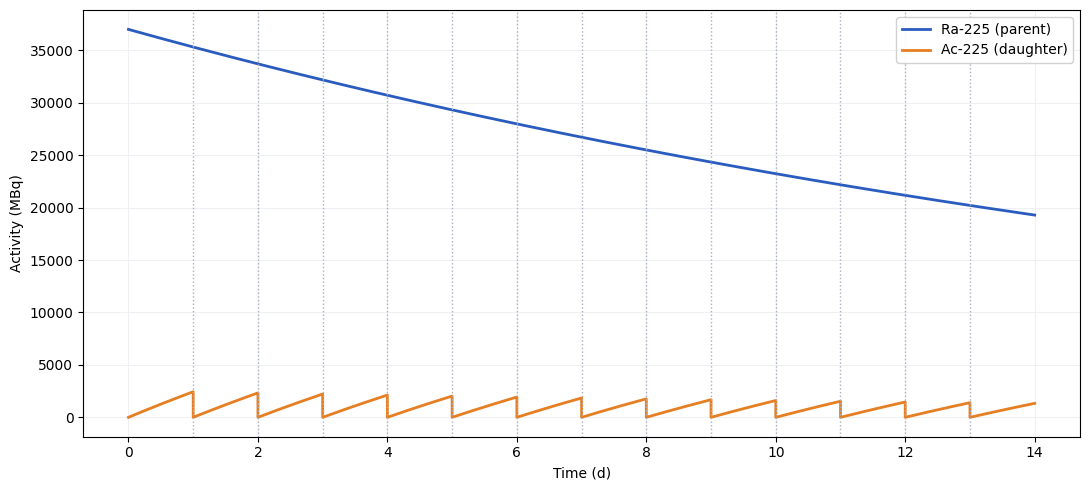

In [14]:
_COLORS_INTER = ['#8e44ad', '#6c3483', '#5b2c6f']

def _role_label(i):
    if i == 0:                        return 'parent'
    if i == len(chain_symbols) - 1:   return 'daughter'
    return 'intermediate'

fig, ax = plt.subplots(figsize=(11, 5))

# Parent and intermediates
for k in range(len(chain_symbols) - 1):
    color = '#2a5cbf' if k == 0 else _COLORS_INTER[(k - 1) % len(_COLORS_INTER)]
    ax.plot(t_plot, from_mbq(activities_MBq[k]),
            color=color, lw=2, label=f'{chain_symbols[k]} ({_role_label(k)})')

# Daughter with explicit drops to zero at each milking event
milking_s_arr = np.array([ts for ts, _ in milking_events])
t_d, y_d = [], []
for i, (ts, act) in enumerate(zip(t_seconds, activities_MBq[-1])):
    t_d.append(ts / 3600 / h_per_unit)
    y_d.append(from_mbq(act))
    if i < len(t_seconds) - 1 and milking_s_arr.size and np.min(np.abs(milking_s_arr - ts)) < 0.5:
        t_d.append(ts / 3600 / h_per_unit)
        y_d.append(0.0)

ax.plot(t_d, y_d, color='#e67e22', lw=2,
        label=f'{chain_symbols[-1]} (daughter)')

# Milking event markers
for ts, _ in milking_events:
    ax.axvline(ts / 3600 / h_per_unit, color='#aab0c0', lw=1, ls='dotted')

# Min yield threshold (theoretical: practical / gen_yield)
if MIN_YIELD is not None:
    ax.axhline(MIN_YIELD / gen_yield, color='#c0392b', lw=1.5, ls='--',
               label='Min yield threshold')

ax.set_xlabel(f'Time ({time_label})')
ax.set_ylabel(f'Activity ({UNITS})')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_facecolor('white')
ax.grid(True, color='#eef0f4')
fig.tight_layout()
plt.show()

## Milking Events

Practical yield per elution (after applying generator yield). Times use the same auto-scaled unit as the chart.

In [ ]:
rows = []
running_mbq = 0.0
for ts, atoms in milking_events:
    yield_mbq     = lambda_daughter * atoms / 1e6 * gen_yield
    running_mbq  += yield_mbq
    rows.append({
        f'Time ({time_label})':      round(ts / 3600 / h_per_unit, 3),
        f'Yield ({UNITS})':          round(from_mbq(yield_mbq), 3),
        f'Cumulative ({UNITS})':     round(from_mbq(running_mbq), 3),
    })

df_events = pd.DataFrame(rows)
df_events

## Cumulative Harvest

Running total of practical yield after each milking.

In [ ]:
times_plot_m = [ts / 3600 / h_per_unit for ts, _ in milking_events]
running = 0.0
cumulative_disp = []
for ts, atoms in milking_events:
    running += from_mbq(lambda_daughter * atoms / 1e6 * gen_yield)
    cumulative_disp.append(running)

if len(times_plot_m) > 1:
    bar_width = (times_plot_m[-1] - times_plot_m[0]) / len(times_plot_m) * 0.7
else:
    bar_width = max(times_plot_m[0] * 0.1, 1.0) if times_plot_m else 1.0

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(times_plot_m, cumulative_disp, width=bar_width, color='#27ae60', alpha=0.85)
ax.set_xlabel(f'Time ({time_label})')
ax.set_ylabel(f'Cumulative yield ({UNITS})')
ax.set_facecolor('white')
ax.grid(True, color='#eef0f4', axis='y')
fig.tight_layout()
plt.show()